# NeuroStat: EEG 통계 피처 기반 비지도 분석

이 노트북은 HMS EEG 데이터를 대상으로 **통계적 피처 추출 → 차원 축소(PCA) → 군집화(K-Means) → 이상치 탐지(Isolation Forest) → artifact 정제 후 재분석**까지의 흐름을 정리한다.

## 프로젝트 목적

EEG 원본 시계열을 직접 분류하기 전에, 각 EEG 파일에서 채널별 통계 피처를 추출하고 비지도학습으로 데이터 구조와 이상 패턴을 탐색한다.

## 전체 분석 흐름

1. 데이터 로드 및 기본 구조 확인  
2. EEG 샘플 시각화  
3. 클래스별 EEG 신호 비교  
4. 환자 기준 train / validation / test 분할  
5. EEG 통계 피처 추출  
6. 결측치 처리 및 표준화  
7. PCA 차원 축소  
8. K-Means 클러스터링  
9. Isolation Forest 기반 이상치 탐지  
10. artifact 확인 및 정제 데이터셋 재분석


## 1. 메타데이터 로드 및 클래스 분포 확인

`train.csv`를 불러와 전체 데이터 크기와 `expert_consensus` 클래스 분포를 확인한다.  
이 단계는 데이터가 어떤 클래스들로 구성되어 있는지, 특정 클래스가 과도하게 많거나 적은지 파악하기 위한 기초 EDA이다.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter plotting backend
%matplotlib inline

# 1. CSV 로드 (가볍게 시작)
df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')


print(df.shape)
print(df['expert_consensus'].value_counts())  # 클래스 분포 확인
print(df.head())

(106800, 15)
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742           2                       8.0          353733   
3  1628180742           3                      18.0          353733   
4  1628180742           4                      24.0          353733   

   spectrogram_sub_id  spectrogram_label_offset_seconds    label_id  \
0                   0                               0.0   127492639   
1                   1                               6.0  3887563113   
2                   2                               8.0  1142670488   
3                   3                              18.0  2718991173   
4                   4                              24.0  308

## 2. EEG parquet 파일 샘플 확인

`eeg_id` 하나를 선택해 실제 EEG parquet 파일을 열고, 시간축 길이와 채널 구성을 확인한다.  
각 채널의 파형을 한 번에 시각화하여 EEG 신호의 기본 형태를 살펴본다.


(10000, 20)
['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']


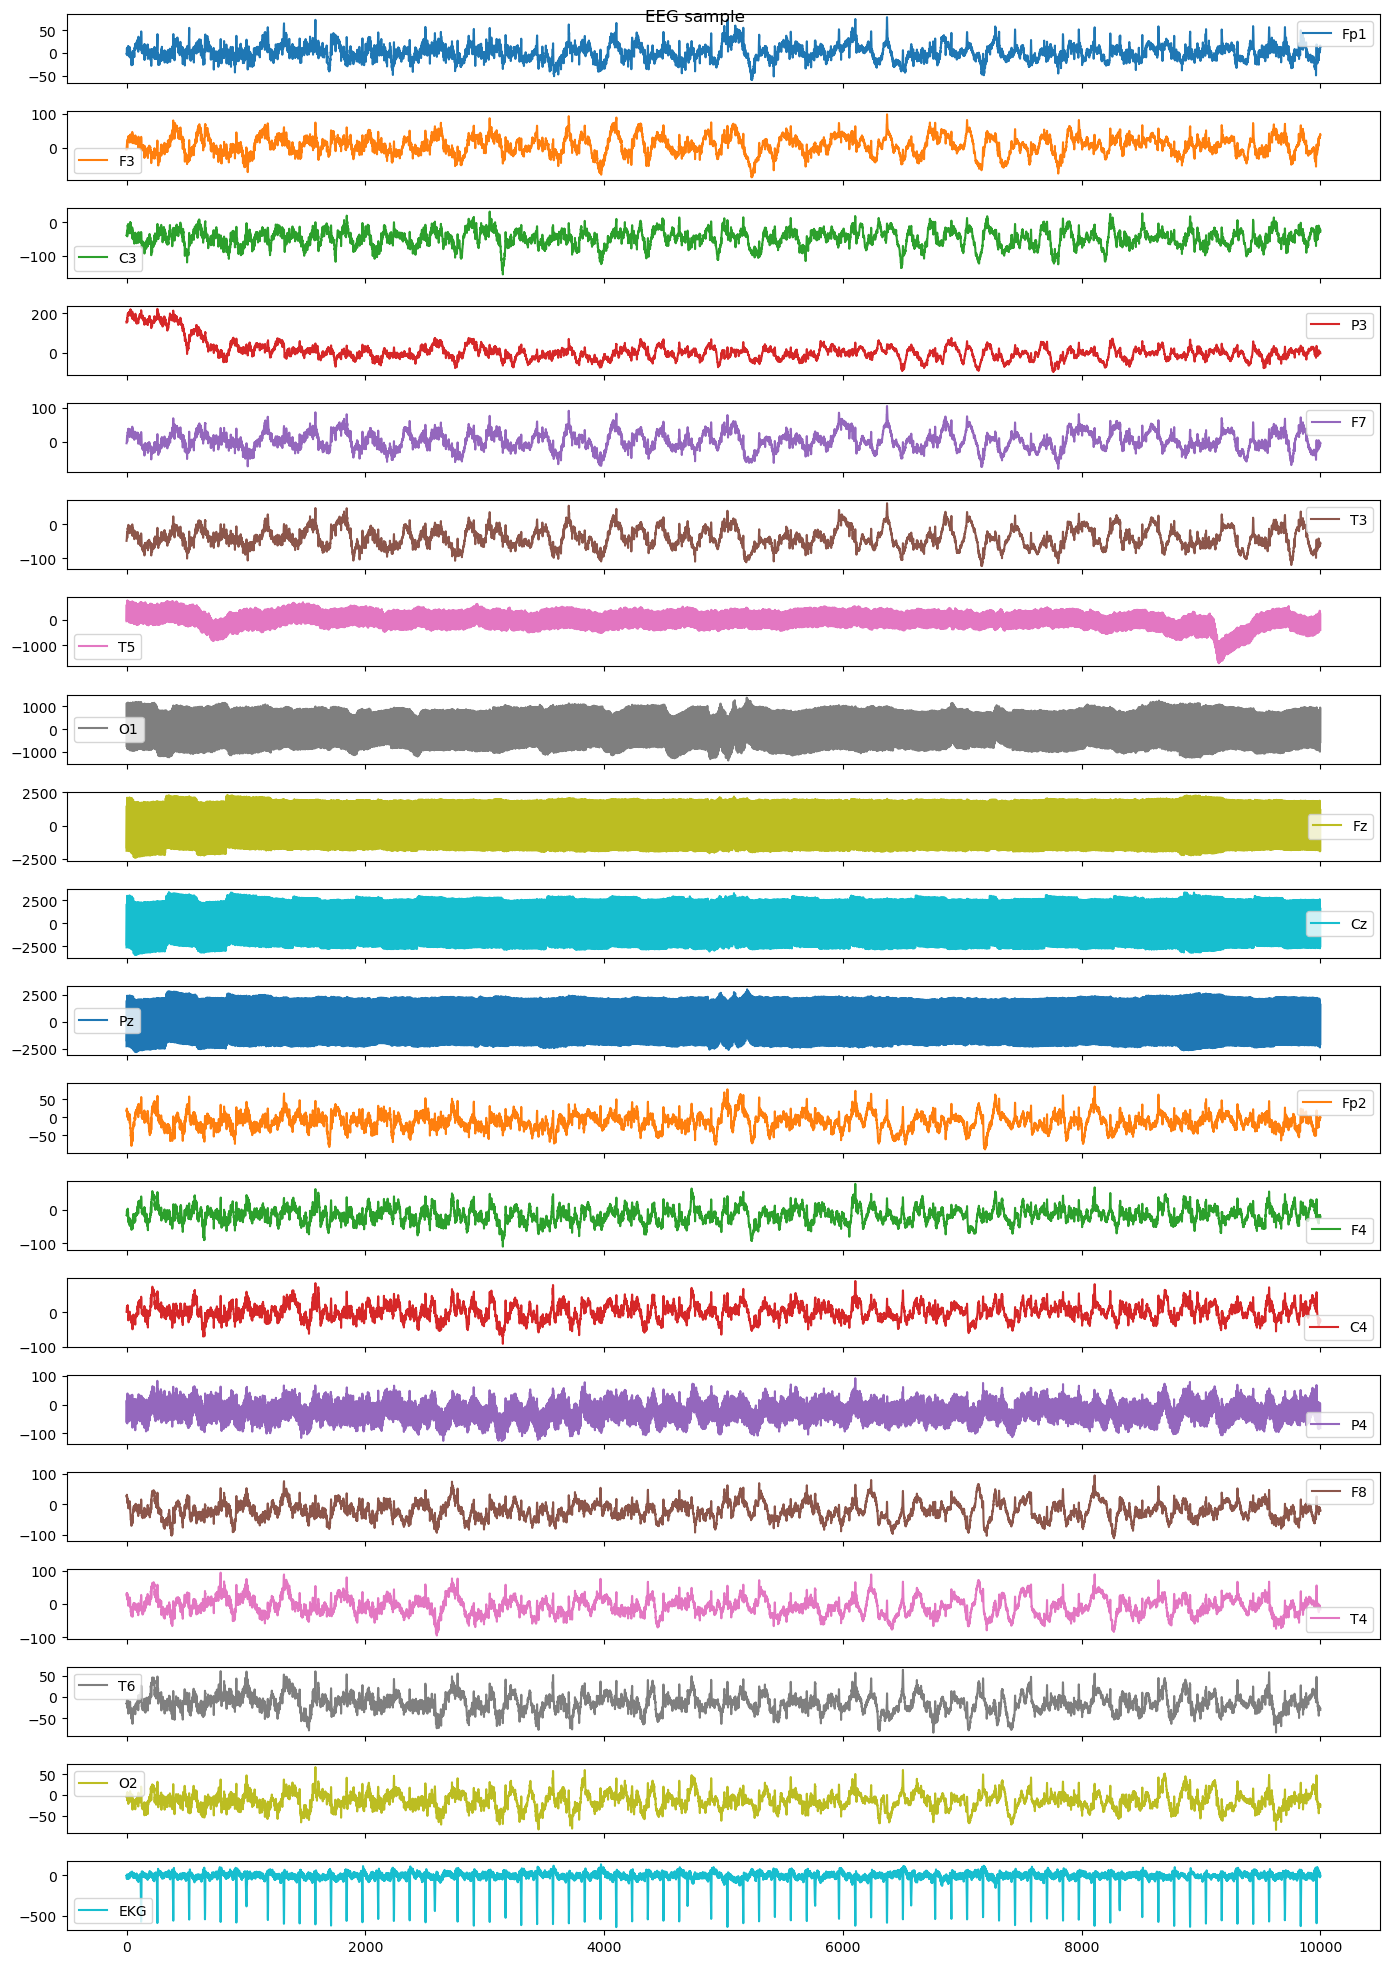

In [177]:
# 하나만 먼저 탐색
sample_id = df['eeg_id'].iloc[0]
eeg = pd.read_parquet(f'/Users/pitzsb1/Documents/train_eegs/{sample_id}.parquet')

print(eeg.shape) # (시간축 길이, 20채널)
print(eeg.columns.tolist())
eeg.plot(subplots=True, figsize=(14, 20), title='EEG sample')
plt.tight_layout()
plt.show()

## 3. EEG 파일 구조 및 기초 통계 확인

특정 EEG 파일을 직접 지정해 shape, column, dtype, 앞부분 데이터, 기초 통계를 확인한다.  
이 단계는 이후 피처 추출 시 어떤 채널과 값 범위를 다루는지 확인하는 과정이다.


In [50]:
import pandas as pd

# 하나만 먼저 열기
eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

print("Shape:", eeg.shape)          # (행 수=시간축, 열 수=채널)
print("\nColumns:", eeg.columns.tolist())
print("\nDtype:\n", eeg.dtypes)
print("\n앞부분:\n", eeg.head())
print("\n기초 통계:\n", eeg.describe())

Shape: (10000, 20)

Columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']

Dtype:
 Fp1    float32
F3     float32
C3     float32
P3     float32
F7     float32
T3     float32
T5     float32
O1     float32
Fz     float32
Cz     float32
Pz     float32
Fp2    float32
F4     float32
C4     float32
P4     float32
F8     float32
T4     float32
T6     float32
O2     float32
EKG    float32
dtype: object

앞부분:
           Fp1          F3         C3         P3          F7          T3  \
0 -105.849998  -89.230003 -79.459999 -49.230000  -99.730003  -87.769997   
1  -85.470001  -75.070000 -60.259998 -38.919998  -73.080002  -87.510002   
2    8.840000   34.849998  56.430000  67.970001   48.099998   25.350000   
3  -56.320000  -37.279999 -28.100000  -2.820000  -43.430000  -35.049999   
4 -110.139999 -104.519997 -96.879997 -70.250000 -111.660004 -114.430000   

          T5         O1         Fz         Cz         Pz        Fp

### 분석 메모

# 1. Data Loading

HMS EEG 데이터를 불러온다.

- EEG parquet 파일 로드
- EKG 채널 제외
- 기본 구조 확인


## 4. EKG 제외 후 EEG 채널 시각화

EEG 분석에서는 뇌파 채널을 중심으로 보기 위해 `EKG` 채널을 제외하고 시각화한다.  
각 채널별 파형을 따로 그려 신호의 진폭, 튐, 결측 또는 artifact 가능성을 육안으로 확인한다.


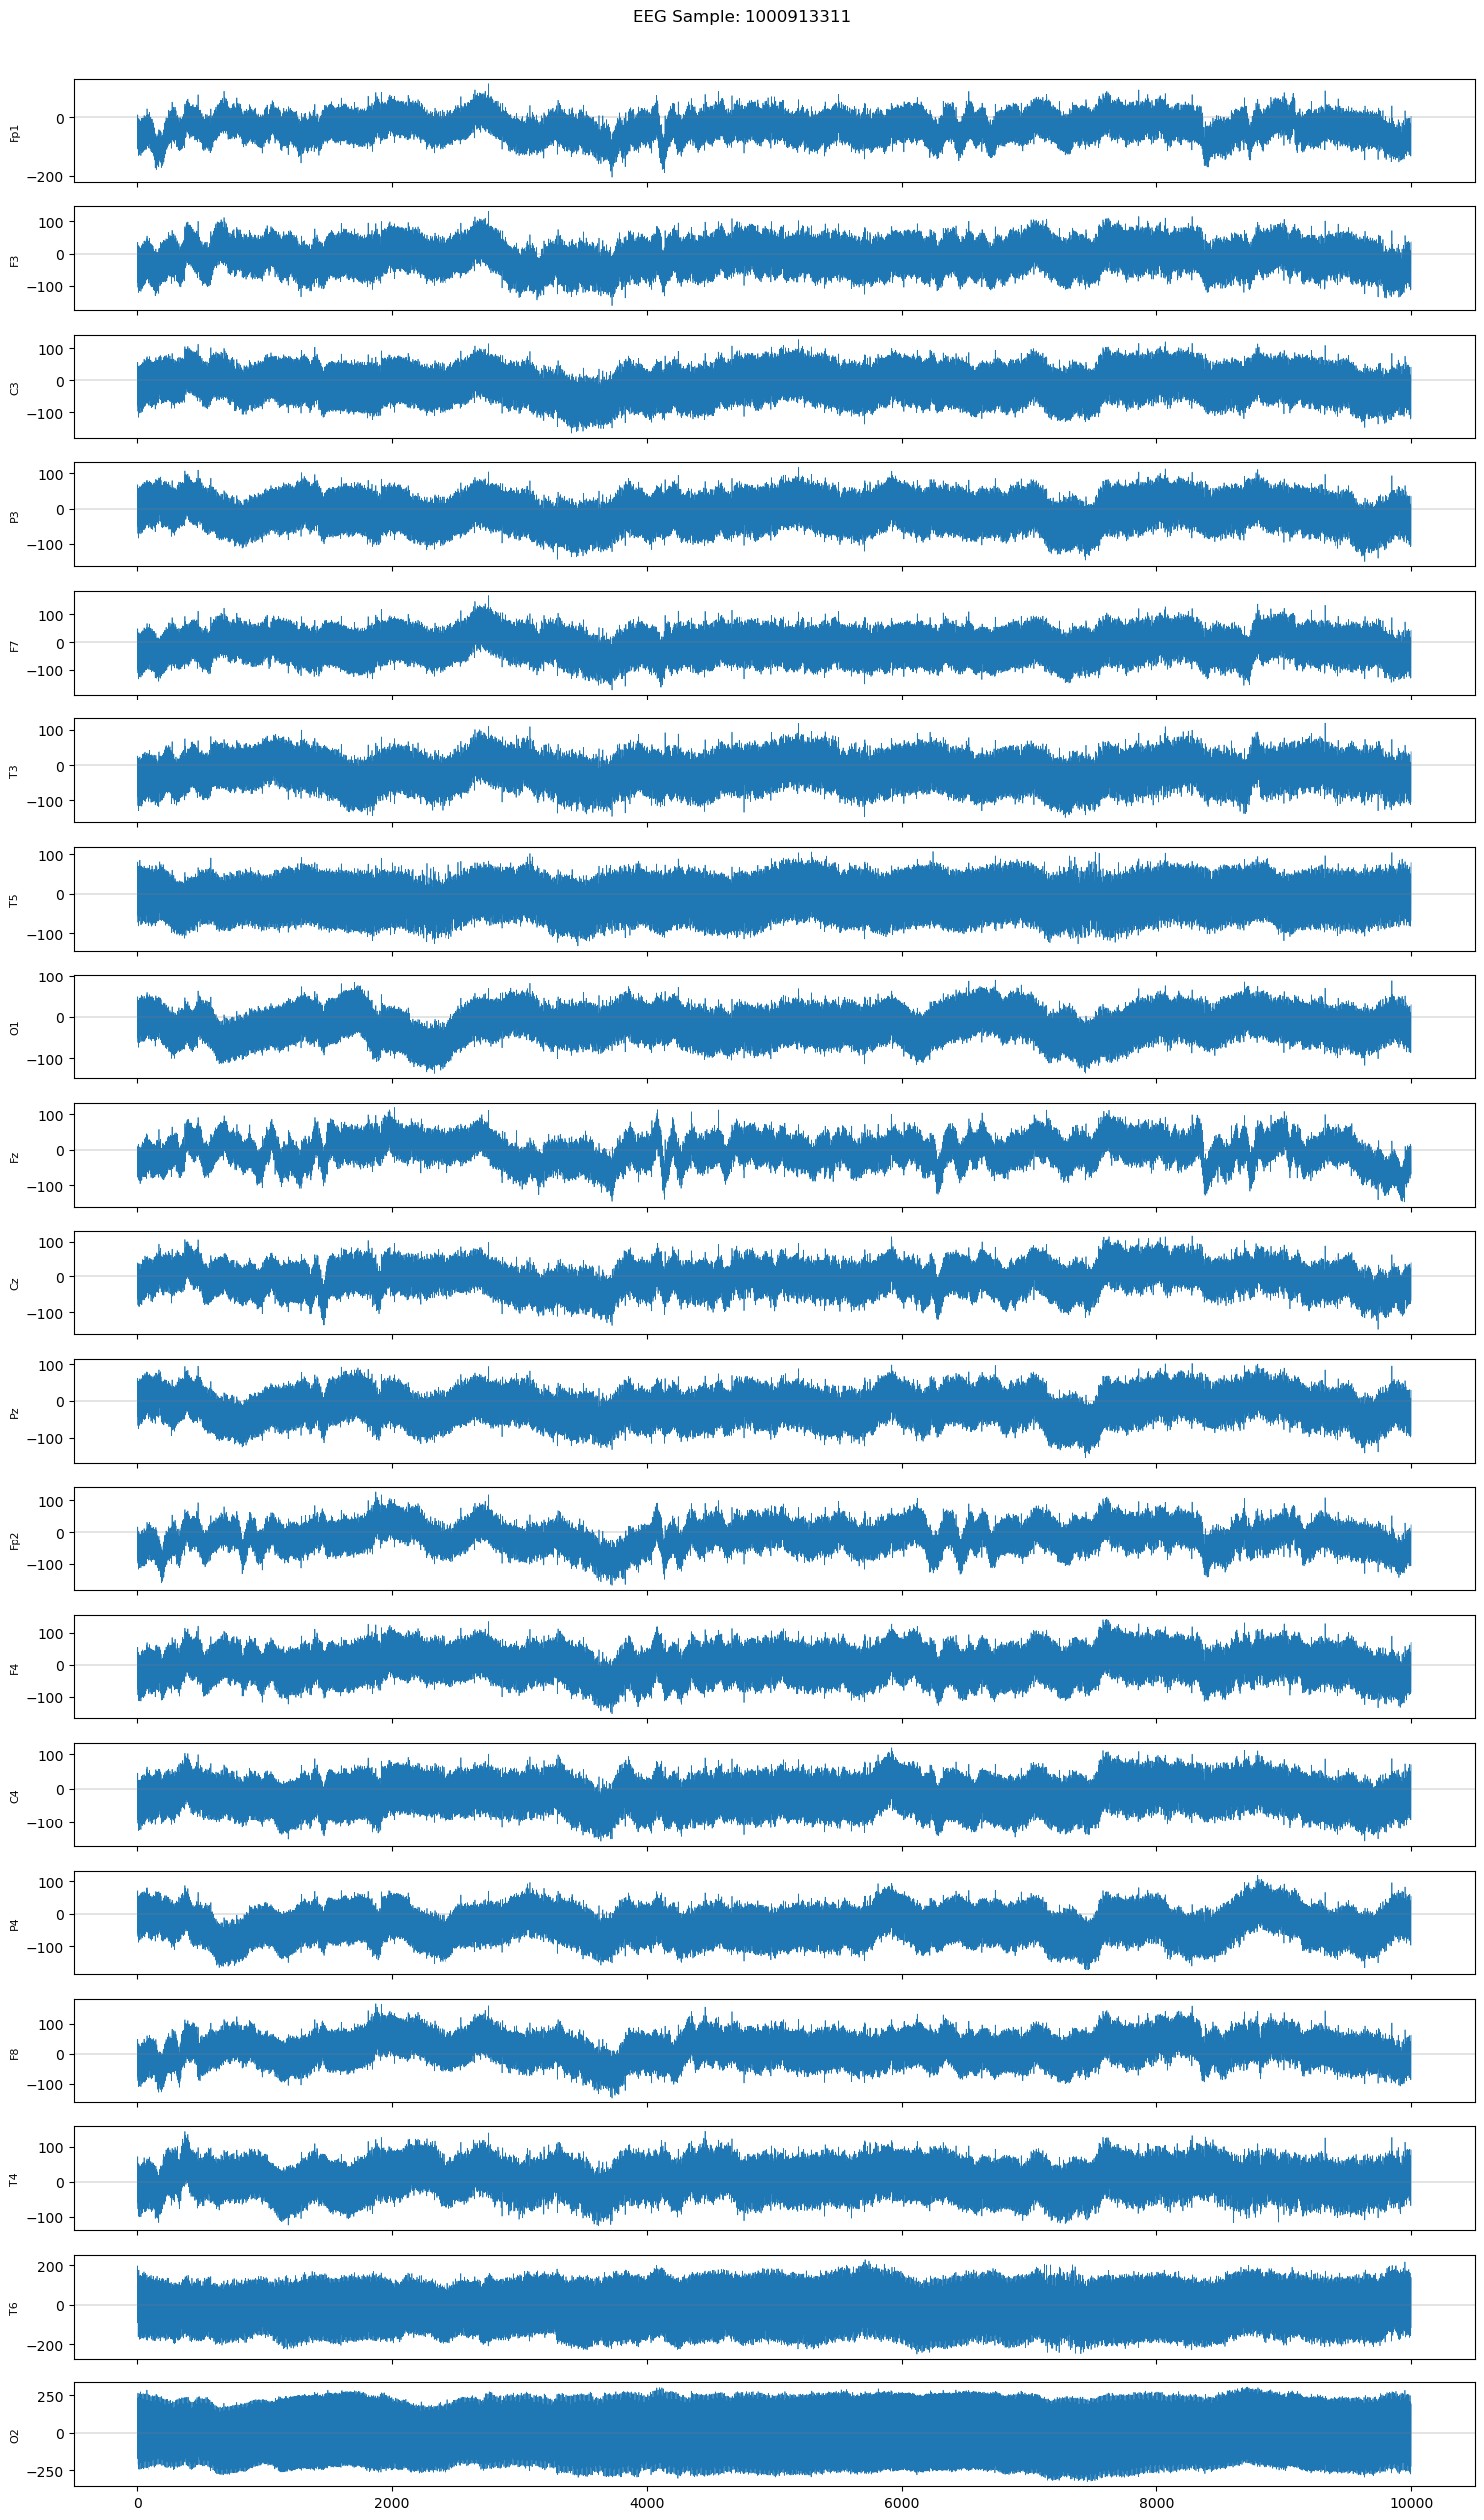

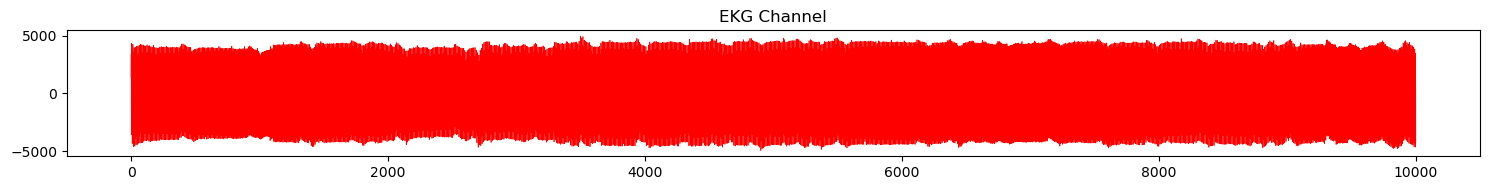

In [51]:
import matplotlib.pyplot as plt

eeg = pd.read_parquet('/Users/pitzsb1/Documents/train_eegs/1000913311.parquet')

# EEG 채널만 (EKG 제외)
eeg_channels = [c for c in eeg.columns if c != 'EKG']

fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(15, 25), sharex=True)

for i, ch in enumerate(eeg_channels):
    axes[i].plot(eeg[ch].values, linewidth=0.5)
    axes[i].set_ylabel(ch, fontsize=8)
    axes[i].axhline(0, color='gray', linewidth=0.3)

plt.suptitle('EEG Sample: 1000913311', y=1.01)
plt.tight_layout()
plt.show()

# EKG 별도 시각화
plt.figure(figsize=(15, 2))
plt.plot(eeg['EKG'].values, linewidth=0.5, color='red')
plt.title('EKG Channel')
plt.tight_layout()
plt.show()

## 5. 특정 EEG의 라벨 정보 확인

시각화한 EEG 샘플이 어떤 `expert_consensus` 라벨을 가지는지 확인한다.  
또한 seizure, LPD, GPD, LRDA, GRDA, Other vote 값을 함께 보면서 전문가 투표 분포를 확인한다.


In [52]:
df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')
print(df[df['eeg_id'] == 1000913311][['eeg_id', 'expert_consensus', 'seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']])

          eeg_id expert_consensus  seizure_vote  lpd_vote  gpd_vote  \
9529  1000913311            Other             0         0         0   

      lrda_vote  grda_vote  other_vote  
9529          0          0           2  


## 6. 전체 train.csv 요약 확인

전체 메타데이터의 shape, 클래스 분포, 결측치, 앞부분 데이터를 다시 확인한다.  
본격적인 분석 전에 데이터셋의 기본 상태를 점검하는 단계이다.


In [53]:
import pandas as pd

df = pd.read_csv('/Users/pitzsb1/Documents/HBAC/train.csv')

print("Shape:", df.shape)
print("\n클래스 분포:")
print(df['expert_consensus'].value_counts())
print("\n결측치:")
print(df.isnull().sum())
print("\n앞부분:")
print(df.head())

Shape: (106800, 15)

클래스 분포:
expert_consensus
Seizure    20933
GRDA       18861
Other      18808
GPD        16702
LRDA       16640
LPD        14856
Name: count, dtype: int64

결측치:
eeg_id                              0
eeg_sub_id                          0
eeg_label_offset_seconds            0
spectrogram_id                      0
spectrogram_sub_id                  0
spectrogram_label_offset_seconds    0
label_id                            0
patient_id                          0
expert_consensus                    0
seizure_vote                        0
lpd_vote                            0
gpd_vote                            0
lrda_vote                           0
grda_vote                           0
other_vote                          0
dtype: int64

앞부분:
       eeg_id  eeg_sub_id  eeg_label_offset_seconds  spectrogram_id  \
0  1628180742           0                       0.0          353733   
1  1628180742           1                       6.0          353733   
2  1628180742     